In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
#Loading the data
data = pd.read_csv('Clean_data.csv')
data['original_order'] = range(len(data))
data = data.sort_values(['year', 'original_order']).reset_index(drop=True)
data.head(20)

,year,Stage Name,Home Team Name,rank_home,Away Team Name,rank_away,Home Team Score,Away Team Score,total_goals,rank_diff,points_diff,Result,total.points_home,total.points_away,favourite,original_order
0,1994,group stage,United States,22.0,Switzerland,7.0,1,1,2,15.0,-10.0,draw,48.0,58.0,Away Team,448
1,1994,group stage,Italy,3.0,Republic of Ireland,7.0,0,1,1,-4.0,3.0,away team win,61.0,58.0,Home Team,449
2,1994,group stage,Colombia,17.0,Romania,10.0,1,3,4,7.0,-4.0,away team win,53.0,57.0,Away Team,450
3,1994,group stage,Belgium,24.0,Morocco,32.0,1,0,1,-8.0,4.0,home team win,47.0,43.0,Home Team,451
4,1994,group stage,United States,22.0,Colombia,17.0,2,1,3,5.0,-5.0,home team win,48.0,53.0,Away Team,452
5,1994,group stage,Italy,3.0,Norway,7.0,1,0,1,-4.0,3.0,home team win,61.0,58.0,Home Team,453
6,1994,group stage,South Korea,34.0,Bolivia,42.0,0,0,0,-8.0,4.0,draw,41.0,37.0,Home Team,454
7,1994,group stage,Mexico,12.0,Republic of Ireland,7.0,2,1,3,5.0,-4.0,home team win,54.0,58.0,Away Team,455
8,1994,group stage,Argentina,10.0,Greece,27.0,4,0,4,-17.0,12.0,home team win,57.0,45.0,Home Team,456
9,1994,group stage,Germany,3.0,Spain,2.0,1,1,2,1.0,-1.0,draw,61.0,62.0,Away Team,457


In [50]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               500 non-null    int64  
 1   Stage Name         500 non-null    str    
 2   Home Team Name     500 non-null    str    
 3   rank_home          500 non-null    float64
 4   Away Team Name     500 non-null    str    
 5   rank_away          500 non-null    float64
 6   Home Team Score    500 non-null    int64  
 7   Away Team Score    500 non-null    int64  
 8   total_goals        500 non-null    int64  
 9   rank_diff          500 non-null    float64
 10  points_diff        500 non-null    float64
 11  Result             500 non-null    str    
 12  total.points_home  500 non-null    float64
 13  total.points_away  500 non-null    float64
 14  favourite          500 non-null    str    
 15  original_order     500 non-null    int64  
dtypes: float64(6), int64(5), str(5)
memor

# --- Feature Engineering ---

In [51]:
# Points ration
data['points_ratio'] = data['total.points_home'] / (data['total.points_away'] + 1e-6)

# Strength according to rank
data['home_top5'] = (data['rank_home'] <= 5).astype(int)
data['home_top10'] = (data['rank_home'] <= 10).astype(int)
data['home_top20'] = (data['rank_home'] <= 20).astype(int)
data['away_top5'] = (data['rank_away'] <= 5).astype(int)
data['away_top10'] = (data['rank_away'] <= 10).astype(int)
data['away_top20'] = (data['rank_away'] <= 20).astype(int)

# [Last 5 matches] by using lag features
data['last_5score_home'] = data.groupby('Home Team Name')['Home Team Score'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean().fillna(1.2)
)

data['last_5conceded_home'] = data.groupby('Home Team Name')['Away Team Score'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean().fillna(1.2)
)

data['last_5score_away'] = data.groupby('Away Team Name')['Away Team Score'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean().fillna(1.2)
)
data['last_5conceded_away'] = data.groupby('Away Team Name')['Home Team Score'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean().fillna(1.2)
)

# Attacking and Defensing strength
data['Home_attack_strength'] = data['last_5score_home'] / (data['last_5conceded_away'] + 1e-6)
data['Home_defence_strength'] = data['last_5conceded_home'] / (data['last_5score_away'] + 1e-6)
data['Away_attack_strength'] = data['last_5score_away'] / (data['last_5conceded_home'] + 1e-6)
data['Away_defence_strength'] = data['last_5conceded_home'] / (data['last_5score_home'] + 1e-6)

In [52]:
# Tournament Context
data['is_group'] = (data['Stage Name'] == 'group stage').astype(int)
data['is_knockout'] = data['Stage Name'].isin(['round of 16', 'quater-finals', 'semi-finals', 'final', 'third-place match']).astype(int)
data['is_final'] = (data['Stage Name'] == 'final').astype(int)

# Head to Head
def get_h2h(row, data):
    H_2_H = data[
    (
      ((data['Home Team Name'] == row['Home Team Name']) & (data['Away Team Name'] == row['Away Team Name']))
      |
      ((data['Home Team Name'] == row['Away Team Name']) & (data['Away Team Name'] == row['Home Team Name']))
    )
    & (data['year'] < row['year'])
]

    if len(H_2_H) == 0:
        return 0, 2.5, 0.5  # No history, assume average goals and 50% win rate
    
    avg_goals = (H_2_H['Home Team Score'] + H_2_H['Away Team Score']).mean()
    home_win = H_2_H[
        ((H_2_H['Home Team Name'] == row['Home Team Name']) & (H_2_H['Home Team Score'] > H_2_H['Away Team Score']))
        |
        ((H_2_H['Away Team Name'] == row['Home Team Name']) & (H_2_H['Away Team Score'] > H_2_H['Home Team Score']))
    ].shape[0]
    return len(H_2_H), avg_goals, home_win

data[['h2h_count', 'h2h_avg_goals', 'h2h_home_win_rate']] = data.apply(
    lambda x: pd.Series(get_h2h(x, data)), axis=1
)

In [53]:
# data = data.to_csv('Updated_data.csv', index=False)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 37 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   year                   500 non-null    int64  
 1   Stage Name             500 non-null    str    
 2   Home Team Name         500 non-null    str    
 3   rank_home              500 non-null    float64
 4   Away Team Name         500 non-null    str    
 5   rank_away              500 non-null    float64
 6   Home Team Score        500 non-null    int64  
 7   Away Team Score        500 non-null    int64  
 8   total_goals            500 non-null    int64  
 9   rank_diff              500 non-null    float64
 10  points_diff            500 non-null    float64
 11  Result                 500 non-null    str    
 12  total.points_home      500 non-null    float64
 13  total.points_away      500 non-null    float64
 14  favourite              500 non-null    str    
 15  original_order   

# --- Visualizations ---

C:\Users\HomePC\AppData\Local\Temp\ipykernel_12348\2747863100.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Result', y='points_diff', ax=axes[1], palette='Set2')
C:\Users\HomePC\AppData\Local\Temp\ipykernel_12348\2747863100.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


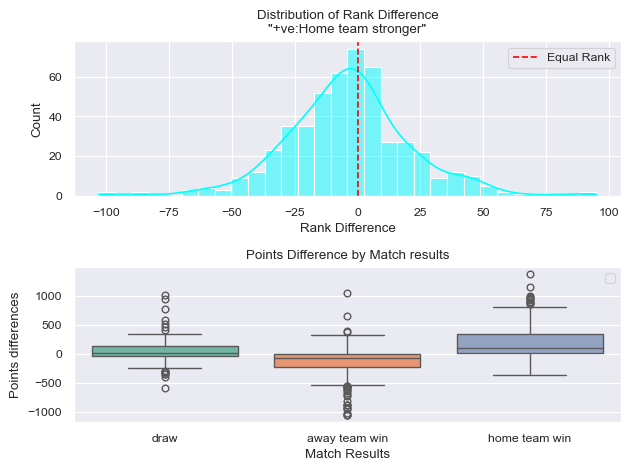

In [54]:
#defaults
sns.set_theme(context='paper', style='darkgrid')

#Ranking patterns
fig, axes = plt.subplots(2)
sns.histplot(data=data, x='rank_diff', bins=30, kde=True, ax=axes[0], color='aqua')
axes[0].axvline(0, color='red', linestyle='--', label='Equal Rank')
axes[0].set_title('Distribution of Rank Difference\n"+ve:Home team stronger"')
axes[0].set_xlabel('Rank Difference')
axes[0].legend()

#Points difference Vs Results
sns.boxplot(data=data, x='Result', y='points_diff', ax=axes[1], palette='Set2')
axes[1].set_title('Points Difference by Match results')
axes[1].set_xlabel('Match Results')
axes[1].set_ylabel('Points differences')
axes[1].legend()

plt.tight_layout()
plt.show()

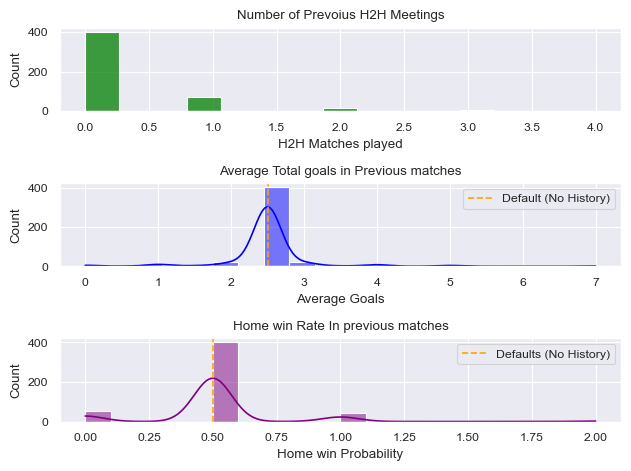

In [55]:
#H2H Features
fig, axes = plt.subplots(3)

#Count of prevoius matches h2h
sns.histplot(data=data, x='h2h_count', bins=15, ax=axes[0], color='green')
axes[0].set_title('Number of Prevoius H2H Meetings')
axes[0].set_xlabel('H2H Matches played')

#Average goals distribution
sns.histplot(data=data, x='h2h_avg_goals', bins=20, kde=True, ax=axes[1], color='blue')
axes[1].axvline(2.5, color='orange', linestyle='--', label='Default (No History)')
axes[1].set_title('Average Total goals in Previous matches')
axes[1].set_xlabel('Average Goals')
axes[1].legend()

#Home win Rate
sns.histplot(data=data, x='h2h_home_win_rate', bins=20, kde=True, ax=axes[2], color='purple')
axes[2].axvline(0.5, color='orange', linestyle='--', label='Defaults (No History)')
axes[2].set_title('Home win Rate In previous matches')
axes[2].set_xlabel('Home win Probability')
axes[2].legend()

plt.tight_layout()
plt.show()

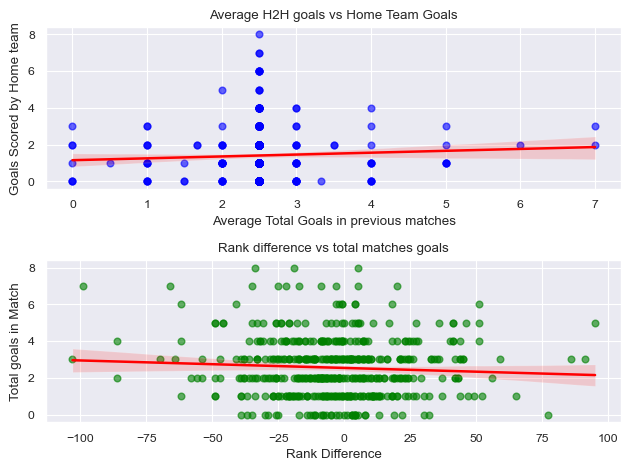

In [56]:
# Strength Patterns
fig, axes = plt.subplots(2)

#Home Attack strength vs goals
sns.regplot(data, x='h2h_avg_goals', y='Home Team Score',
            scatter_kws={'alpha':0.6, 'color':'blue'},
            line_kws={'color':'red'}, ax=axes[0])
axes[0].set_title('Average H2H goals vs Home Team Goals')
axes[0].set_xlabel('Average Total Goals in previous matches')
axes[0].set_ylabel('Goals Scored by Home team')

#Rank diff vs total goals
sns.regplot(data, x='rank_diff', y='total_goals',
            scatter_kws={'alpha':0.6, 'color':'green'},
            line_kws={'color':'red'}, ax=axes[1])
axes[1].set_title('Rank difference vs total matches goals')
axes[1].set_xlabel('Rank Difference')
axes[1].set_ylabel('Total goals in Match')

plt.tight_layout()
plt.show()

C:\Users\HomePC\AppData\Local\Temp\ipykernel_12348\783695308.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data, x='Stage Name', y='total_goals',palette='viridis')


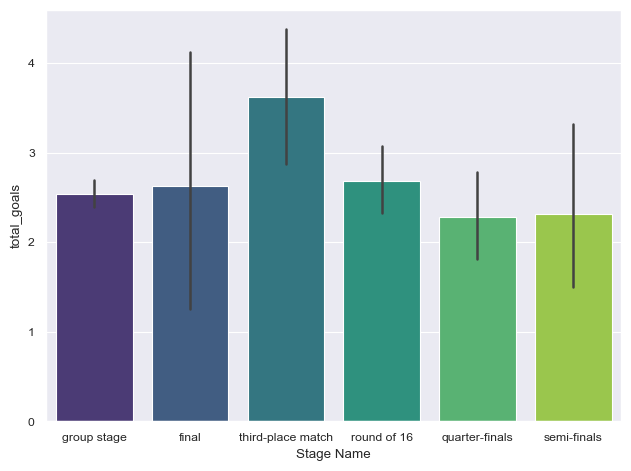

In [57]:
#Stage patterns
#Average goals in stages
sns.barplot(data, x='Stage Name', y='total_goals',palette='viridis')
axes[0].set_title('Toatal goals per stage')
axes[0].set_xlabel('Stage Name')
axes[0].set_ylabel('Total goals')
axes[0].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

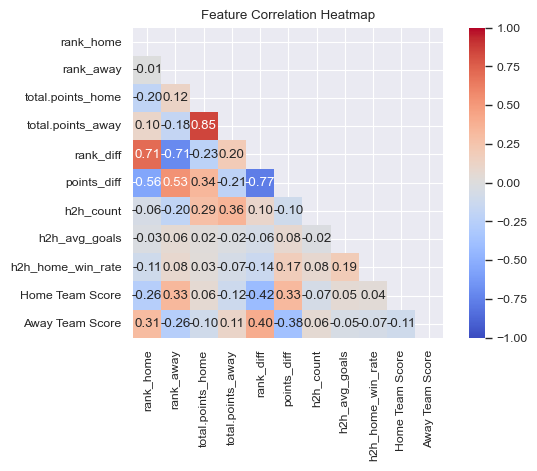

In [58]:
#Correlation matrix
num_cols = ['rank_home', 'rank_away', 'total.points_home', 'total.points_away', 'rank_diff', 'points_diff', 'h2h_count',
            'h2h_avg_goals', 'h2h_home_win_rate', 'Home Team Score', 'Away Team Score']
corr_feat = data[num_cols].corr()
mask = np.triu(np.ones_like(corr_feat, dtype=bool))
sns.heatmap(corr_feat, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# --- Modeling ---
1. Correct Score Model
2. Match Outcome Model
3. World cup winner Model

#### 1. Correct Score Model

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

In [60]:
# Features selection
teams = pd.read_csv('matches.csv')
data_encoded = data.copy()
teams['Home team name'] = teams['Home team name'].replace('Czechia', 'Czech Republic')
teams['away team name'] = teams['away team name'].replace('Czechia', 'Czech Republic')
all_teams = pd.concat([data_encoded['Home Team Name'], data_encoded['Away Team Name'],
                       teams['Home team name'], teams['away team name']]).unique()

team_encoder = LabelEncoder()
team_encoder.fit(all_teams)
data_encoded['Home Team Encoded'] = team_encoder.transform(data_encoded['Home Team Name'])
data_encoded['Away Team Encoded'] = team_encoder.transform(data_encoded['Away Team Name'])

X_score_feat = data_encoded[[ 'Home Team Encoded', 'Away Team Encoded', 'rank_diff', 'points_diff', 'points_ratio', 'home_top5', 'home_top10', 'home_top20',
                             'away_top5', 'away_top10', 'away_top20', 'last_5score_home', 'last_5conceded_home',
                             'last_5score_away', 'last_5conceded_away', 'Home_attack_strength', 'Home_defence_strength',
                             'Away_attack_strength', 'Away_defence_strength', 'is_group', 'is_knockout', 'is_final',
                             'h2h_count', 'h2h_avg_goals', 'h2h_home_win_rate']]
print(f'SHAPE OF FEATURES:{X_score_feat.shape}')

#Target selection
y_home_score = data_encoded['Home Team Score']
y_away_score = data_encoded['Away Team Score']
print(f'SHAPE OF TARGETS: Home = {y_home_score.shape}', f'Away = {y_away_score.shape}')

SHAPE OF FEATURES:(500, 25)
SHAPE OF TARGETS: Home = (500,) Away = (500,)


In [61]:
data_encoded.to_csv('Encoded data.csv', index=False)

In [62]:
scaler = StandardScaler()

#Splitting the data
Xs_train, Xs_val, yh_train, yh_val, ya_train, ya_val = train_test_split(X_score_feat, y_home_score, y_away_score,
                                                                        test_size=0.2, random_state=42)

#Scaling features
Xs_train_scaled = scaler.fit_transform(Xs_train)
Xs_val_scaled = scaler.transform(Xs_val)
scaler = joblib.dump(scaler, 'scaler.pkl')

#Modelling
model_home_score = XGBRegressor(objective='count:poisson', n_estimators=200, learning_rate=0.04, max_depth=3,
                                random_state=42, subsample=0.8, colsample_bytree=0.8)
model_away_score = XGBRegressor(objective='count:poisson', n_estimators=200, learning_rate=0.04, max_depth=3,
                                random_state=42, subsample=0.8, colsample_bytree=0.8)

#Fitting the model[training]
model_home_score.fit(Xs_train_scaled, yh_train)
model_away_score.fit(Xs_train_scaled, ya_train)

#Evaluating the models
            #1Home evaluation
mse_home = mean_squared_error(yh_val, model_home_score.predict(Xs_val_scaled))
mae_home = mean_absolute_error(yh_val, model_home_score.predict(Xs_val_scaled))
print('=='*50)
print(f'The mean square error for home model score is: {mse_home}')
print(f'The mean absolute error for home model score is: {mae_home}')
print(f'The R-squared value for home model score is: {r2_score(yh_val, model_home_score.predict(Xs_val_scaled))}')

            #2.Away Evaluation
mse_away = mean_squared_error(ya_val, model_away_score.predict(Xs_val_scaled))
mae_away = mean_absolute_error(ya_val, model_away_score.predict(Xs_val_scaled))
print('\n')
print('=='*50)
print(f'The mean square error for away model score is: {mse_away}')
print(f'The mean absolute error for away model score is: {mae_away}')
print(f'The R-squared value for away model score is: {r2_score(ya_val, model_away_score.predict(Xs_val_scaled))}')

The mean square error for home model score is: 1.2984209060668945
The mean absolute error for home model score is: 0.8737292289733887
The R-squared value for home model score is: 0.14442479610443115


The mean square error for away model score is: 0.9583791494369507
The mean absolute error for away model score is: 0.7937646508216858
The R-squared value for away model score is: 0.14208292961120605


# Model percistence

In [63]:
import joblib

joblib.dump(model_home_score, 'home_score_model.pkl')
joblib.dump(model_away_score, 'away_score_model.pkl')

['away_score_model.pkl']

In [64]:
data_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 39 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   year                   500 non-null    int64  
 1   Stage Name             500 non-null    str    
 2   Home Team Name         500 non-null    str    
 3   rank_home              500 non-null    float64
 4   Away Team Name         500 non-null    str    
 5   rank_away              500 non-null    float64
 6   Home Team Score        500 non-null    int64  
 7   Away Team Score        500 non-null    int64  
 8   total_goals            500 non-null    int64  
 9   rank_diff              500 non-null    float64
 10  points_diff            500 non-null    float64
 11  Result                 500 non-null    str    
 12  total.points_home      500 non-null    float64
 13  total.points_away      500 non-null    float64
 14  favourite              500 non-null    str    
 15  original_order   

# 2026 PREDICTION

In [65]:
teams

,year,stage name,Home team name,rank home,away team name,rank away,total points home,prevoius points home,total points away,previous points away,head to head,goals_in_head to head meetings,last_5matches_goals_home,last_5matches_conceded_home,last_5matches_goals_away,last_5matches_conceded_away,home_win_rate_from_h2h
0,2026,First Stage Group A,Mexico,15,South Africa,60,1681.0,1675.5,1429.0,1425.0,4,13,8,4,5,6,0.50
1,2026,First Stage Group A,South Korea,25,Czech Republic,41,1588.0,1591.5,1501.0,1498.0,3,10,7,5,6,5,0.33
2,2026,First Stage Group A,Czech Republic,41,South Africa,60,1501.0,1498.0,1429.0,1425.0,1,3,6,5,5,6,1.00
3,2026,First Stage Group A,Mexico,15,South Korea,25,1681.0,1675.5,1588.0,1591.5,14,44,8,4,7,5,0.57
4,2026,First Stage Group A,Czech Republic,41,Mexico,15,1501.0,1498.0,1681.0,1675.5,2,4,6,5,8,4,0.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,2026,Quarter-Final,Winners Match 95,0,Winners Match 96,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0.00
100,2026,Semi-Final,Winners Match 97,0,Winners Match 98,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0.00
101,2026,Semi-Final,Winners Match 99,0,Winners Match 100,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0.00
102,2026,Third-Place Match,Losers Match 101,0,Losers Match 102,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0.00


# Feature Egineering for 2026 data

In [66]:
#rank difference
teams['rank_diff'] = teams['rank home'] - teams['rank away']
teams['points_diff'] = teams['total points home'] - teams['total points away']
teams['points_ratio'] = teams['total points home'] / (teams['total points away'] + 1e-6)
teams['is_group'] = (teams['stage name'].isin(['First Stage Group A', 'First Stage Group B', 'First Stage Group C', 'First Stage Group D', 'First Stage Group E', 'First Stage Group F', 'First Stage Group G', 'First Stage Group H', 'First Stage Group I', 'First Stage Group J', 'First Stage Group K', 'First Stage Group L'])).astype(int)
teams['is_knockout'] = teams['stage name'].isin(['Round of 32', 'Round of 16', 'Quater-Final', 'Semi-Final', 'Third-Place Match', 'Final Match']).astype(int)
teams['is_final'] = (teams['stage name'] == 'final').astype(int)
teams['home_top5'] = (teams['rank home'] <= 5).astype(int)
teams['home_top10'] = (teams['rank home'] <= 10).astype(int)
teams['home_top20'] = (teams['rank home'] <= 20).astype(int)
teams['away_top5'] = (teams['rank away'] <= 5).astype(int)
teams['away_top10'] = (teams['rank away'] <= 10).astype(int)
teams['away_top20'] = (teams['rank away'] <= 20).astype(int)
teams['home_attack_strength'] = teams['last_5matches_goals_home'] / (teams['last_5matches_conceded_away'] + 1e-6)
teams['home_defence_strength'] = teams['last_5matches_conceded_home'] / (teams['last_5matches_goals_away'] + 1e-6)
teams['away_attack_strength'] = teams['last_5matches_goals_away'] / (teams['last_5matches_conceded_home'] + 1e-6)
teams['away_defence_strength'] = teams['last_5matches_conceded_home'] / (teams['last_5matches_goals_home'] + 1e-6)
teams['Home Team Encoded'] = team_encoder.transform(teams['Home team name'])
teams['Away Team Encoded'] = team_encoder.transform(teams['away team name'])

In [67]:
teams.columns

Index(['year', 'stage name', 'Home team name', 'rank home', 'away team name',
       'rank away', 'total points home', 'prevoius points home',
       'total points away', 'previous points away', 'head to head',
       'goals_in_head to head meetings', 'last_5matches_goals_home',
       'last_5matches_conceded_home', 'last_5matches_goals_away',
       'last_5matches_conceded_away', 'home_win_rate_from_h2h', 'rank_diff',
       'points_diff', 'points_ratio', 'is_group', 'is_knockout', 'is_final',
       'home_top5', 'home_top10', 'home_top20', 'away_top5', 'away_top10',
       'away_top20', 'home_attack_strength', 'home_defence_strength',
       'away_attack_strength', 'away_defence_strength', 'Home Team Encoded',
       'Away Team Encoded'],
      dtype='str')

In [68]:
data_encoded.columns

Index(['year', 'Stage Name', 'Home Team Name', 'rank_home', 'Away Team Name',
       'rank_away', 'Home Team Score', 'Away Team Score', 'total_goals',
       'rank_diff', 'points_diff', 'Result', 'total.points_home',
       'total.points_away', 'favourite', 'original_order', 'points_ratio',
       'home_top5', 'home_top10', 'home_top20', 'away_top5', 'away_top10',
       'away_top20', 'last_5score_home', 'last_5conceded_home',
       'last_5score_away', 'last_5conceded_away', 'Home_attack_strength',
       'Home_defence_strength', 'Away_attack_strength',
       'Away_defence_strength', 'is_group', 'is_knockout', 'is_final',
       'h2h_count', 'h2h_avg_goals', 'h2h_home_win_rate', 'Home Team Encoded',
       'Away Team Encoded'],
      dtype='str')

In [69]:
Xs_2026 = teams[[ 'Home Team Encoded', 'Away Team Encoded', 'rank_diff', 'points_diff', 'points_ratio', 'home_top5', 'home_top10', 'home_top20',
                             'away_top5', 'away_top10', 'away_top20', 'last_5matches_goals_home', 'last_5matches_conceded_home',
                             'last_5matches_goals_away', 'last_5matches_conceded_away', 'home_attack_strength', 'home_defence_strength',
                             'away_attack_strength', 'away_defence_strength', 'is_group', 'is_knockout', 'is_final',
                             'head to head', 'goals_in_head to head meetings', 'home_win_rate_from_h2h']]

Xs_2026.columns = X_score_feat.columns
Xs_2026_scaled = scaler.transform(Xs_2026)

#modelling for 2026 predictions
home_model = joblib.load('home_score_model.pkl')
away_model = joblib.load('away_score_model.pkl')

#predicting
teams['Predicted Home Score'] = np.round(home_model.predict(Xs_2026_scaled)).astype(int)
teams['Predicted Away Score'] = np.round(away_model.predict(Xs_2026_scaled)).astype(int)

#combining the predictions
teams['Predicted Correct Score'] = teams['Predicted Home Score'].astype(str) + '-' + teams['Predicted Away Score'].astype(str)
teams['Predicted Results'] = np.where(
    teams['Predicted Home Score'] > teams['Predicted Away Score'], teams['Home team name'], 
    np.where(teams['Predicted Home Score'] < teams['Predicted Away Score'], teams['away team name'],
    'Draw')
)

#Saving the predictions with only the required columns
correct_model = teams[['Home team name', 'away team name', 'Predicted Home Score', 'Predicted Away Score', 'Predicted Results']]
# correct_model.to_csv('Predicted scores.csv', index=False)

AttributeError: 'list' object has no attribute 'transform'

In [ ]:
data_2026 = teams.drop(['Predicted Home Score','Predicted Away Score', 'Predicted Correct Score', 'Predicted Results'], axis=1, inplace=True)
data_2026 = teams.to_csv('Clean data of 2026 +.csv', index=False)

AttributeError: 'NoneType' object has no attribute 'columns' and no __dict__ for setting new attributes